In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import seaborn as sns
import plotly.express as px
from matplotlib.colors import LogNorm

In [12]:
mapping = {
    'Congo (Kinshasa)': 'Democratic Republic of the Congo',
    'Congo (Brazzaville)': 'Republic of the Congo',
    'US': 'United States of America',
    'USA': 'United States of America',
    'United States': 'United States of America',
    'Tanzania': 'United Republic of Tanzania'
}

In [13]:
dfUsersRatings = pd.read_csv("../data/cleaned/users_ratings.csv")
dfUsersRatings = dfUsersRatings.sample(500_000, random_state=42)
dfUsersRatings

,username,anime_id,status,score,num_watched_episodes
15746837,Tsumaranai-_-,46102,completed,10,13
43781331,LayAnanta,11759,plan_to_watch,0,0
1488006,MooMooFluff,29101,completed,8,6
30838026,Kuloky,8630,completed,0,12
11297766,Kidagakas,40542,completed,8,6
...,...,...,...,...,...
11849799,3dg3m4st3r,7769,completed,0,12
26552551,byverbel,39792,plan_to_watch,0,0
38418464,sirspam0,50461,watching,0,6
26801130,KozuMac,59986,watching,0,2


##### Surprisingly the count of the score increases as the score, this could be happening because a user is more prone to vote if the anime was good

<Axes: xlabel='score', ylabel='Count'>

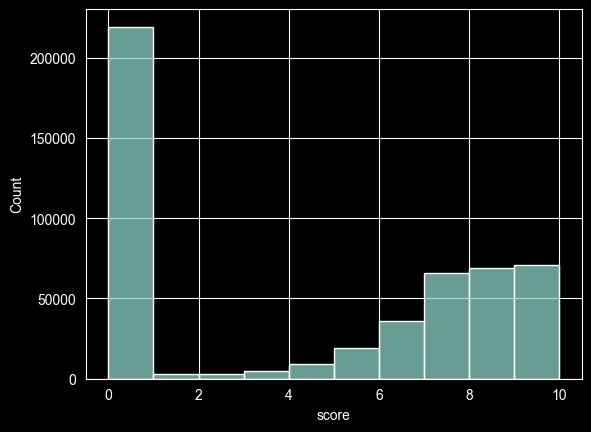

In [14]:
sns.histplot(dfUsersRatings["score"], bins=10)

<Axes: xlabel='status', ylabel='count'>

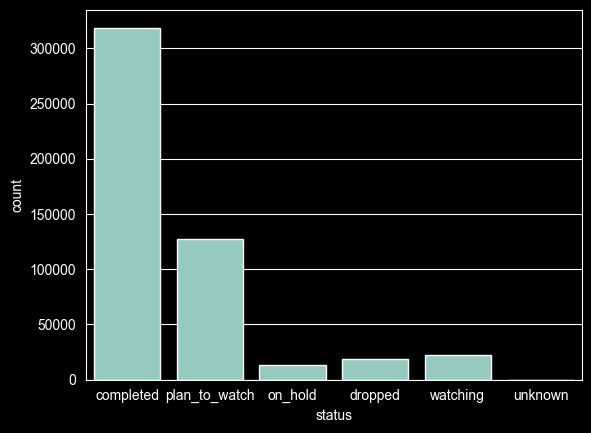

In [15]:
sns.countplot(data=dfUsersRatings, x="status")

##### Here we can see that the number of episodes watched have an impact on the score given by the user. It makes sense because if a user don't like an anime is more prone to drop it

In [16]:
px.scatter(dfUsersRatings, y="num_watched_episodes", x="score", opacity=0.3)

##### Here we can see a high number of anime dropped on lower scores

<Axes: xlabel='status', ylabel='score'>

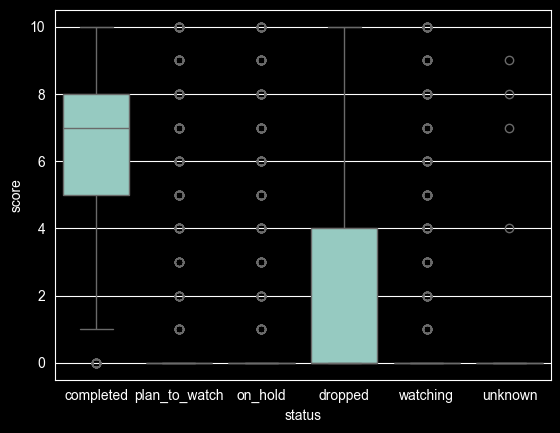

In [17]:
sns.boxplot(data=dfUsersRatings, x="status", y="score")

In [18]:
dfUsersRatings = None

In [19]:
dfUsersFavs = pd.read_csv("../data/cleaned/users_favs.csv")
dfUsersFavs

,Unnamed: 0,username,fav_type,id
0,0,ishikawas,anime,45649
1,1,ishikawas,anime,38680
2,2,ishikawas,anime,795
3,3,ishikawas,anime,37510
4,4,ishikawas,anime,820
...,...,...,...,...
4178738,4178742,vincent0607,character,497
4178739,4178743,vincent0607,character,118739
4178740,4178744,vincent0607,character,188177
4178741,4178745,vincent0607,character,141354


In [20]:
dfAnime = pd.read_csv("../data/cleaned/anime.csv", usecols=["mal_id", "title", "score", "popularity"])
#dfAnime

In [21]:
fav_anime = dfUsersFavs[dfUsersFavs["fav_type"] == "anime"]
fav_anime = fav_anime.drop(columns=["fav_type"])
#fav_anime

In [22]:
dfUsersFavs = None

In [23]:
dfAnime = dfAnime.merge(fav_anime, left_on="mal_id", right_on="id")
fav_anime = None
#dfAnime

In [24]:
top20 = (
    dfAnime.groupby(["id", "title", "score"])
          .size()
          .reset_index(name="num_favs")
          .sort_values("num_favs", ascending=False)
          .head(20)
)
top20

,id,title,score,num_favs
3683,11061,Hunter x Hunter (2011),9.03,31558
3349,9253,Steins;Gate,9.07,30757
2655,5114,Fullmetal Alchemist: Brotherhood,9.10,27886
11,21,One Piece,8.73,27337
4164,16498,Shingeki no Kyojin,8.56,19480
1155,1535,Death Note,8.62,18896
20,30,Shinseiki Evangelion,8.36,15591
8685,52991,Sousou no Frieren,9.29,15409
1183,1575,Code Geass: Hangyaku no Lelouch,8.71,13621
5017,28851,Koe no Katachi,8.93,13574


##### It appears that the number of favorites does not have a huge impact on the score of the anime. Even anime that have a low number of favorites bring an high score. This behavior could be explained by the fact that a user will not put an anime in the favorites if it wasn't good.

In [25]:
dfFav = (
    dfAnime.groupby(["id", "title", "score"])
          .size()
          .reset_index(name="num_favs")
          .sort_values("num_favs", ascending=False)
)

fig = px.scatter(
    dfFav,
    x="num_favs",
    y="score",
    hover_name="title",
    size="num_favs",
    opacity=0.7
)
fig.update_traces(textposition="top center")
fig.show()

In [26]:
dfTemp = dfAnime.groupby("mal_id", as_index=False).first()
dfFav = dfFav.merge(dfTemp[["mal_id", "popularity"]], left_on="id", right_on="mal_id")
dfTemp = None
dfFav = dfFav.drop(columns=["mal_id"])
#dfFav

##### Maybe it was expected to see the popularity of an anime to grow with the score, but as we can see it does not. Actually there is a slow curve going down so low popularity does not mean a low score but maybe low advertisement or just a niche product
###### It's interesting how the more popular an anime is the lower the score is, could that be the result of making a product for a larger type of users making it more mainstream and banal

In [27]:
fig = px.scatter(
    dfFav,
    x="popularity",
    y="score",
    text="title",
    hover_name="title",
    size="popularity",
    opacity=0.7
)
fig.update_traces(text = None)

fig.show()

##### Here we get a closer look of the downward curve

In [28]:
fig.update_xaxes(range = [0, 10000])
fig.show()

In [29]:
dfAnime = None
dfFav = None

##### Let's take a gander on the locations where anime are watched the most

In [30]:
dfUsersProfiles = pd.read_csv("../data/cleaned/users_profiles.csv")
#dfUsersProfiles

In [31]:
gdfCountries = gpd.read_file("../data/country data/ne_10m_admin_0_countries.shp")
#gdfCountries["ADMIN"] = gdfCountries["ADMIN"].replace(mapping)

In [32]:
dfWatched = (
    dfUsersProfiles
    .groupby("location", as_index=False)
    .agg(totalWatched = ("completed", "sum"))
)
gdfWatched = dfWatched.merge(gdfCountries, left_on="location", right_on="ADMIN")
dfWatched = None
gdfWatched = gpd.GeoDataFrame(gdfWatched, geometry="geometry", crs="EPSG:4326")
#gdfWatched

##### The dataset looks incompleted and a lot of countries looks missing, but we can take a look where animes are more watched. Japan is the leader, following United States, Germany and UK. Even tho its a japan product, animes made their way to Europe and America.

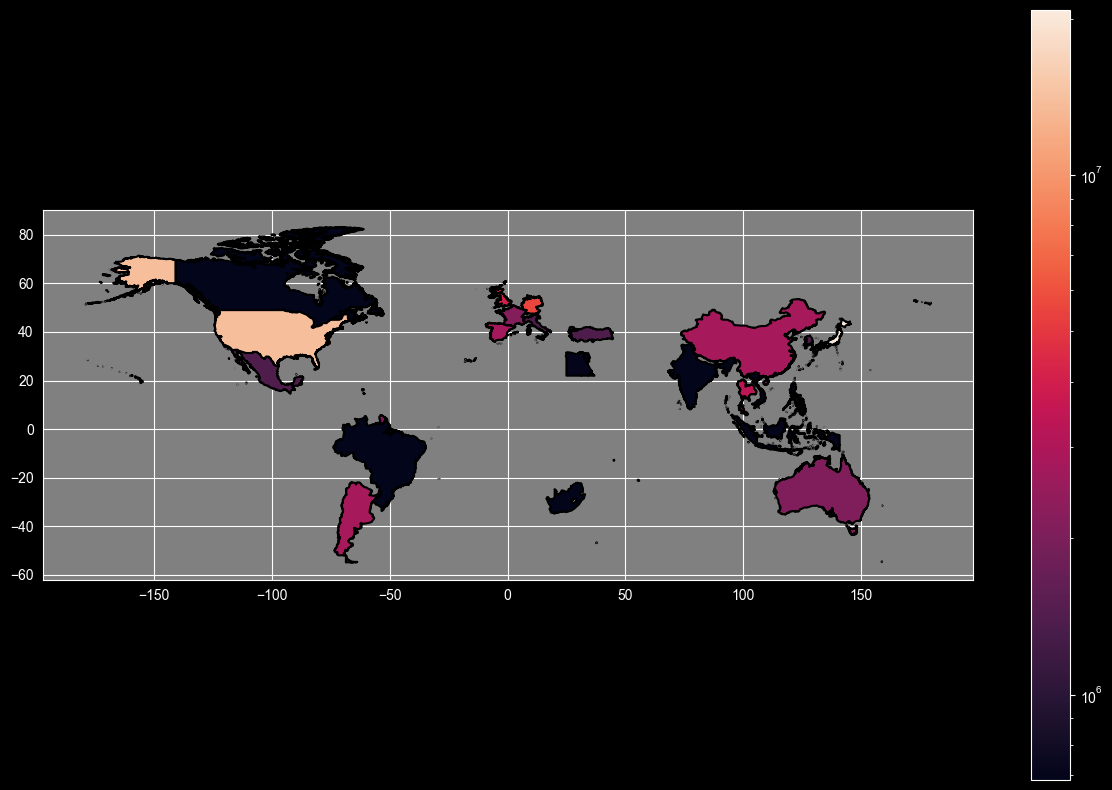

In [33]:
ax = gdfWatched.plot(figsize=(15,10),
                     linewidth=1.5,
                     edgecolor = "black",
                     column = "totalWatched",
                     legend=True,
                     norm=LogNorm()
                     )
ax.set_facecolor("gray")
plt.show()

In [34]:
dfUsersProfiles = None
dfAnime = None